<a href="https://colab.research.google.com/github/shivansh2310/The-elements-of-quantitative-investing-/blob/main/Foundations%2C_Stylized_Facts%2C_%26_The_Linear_Model_(Chapters_1%E2%80%934).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Core concepts

#### A. The Reality of returns



*   Log Returns Vs Simple Retruns: Always use log returns ($r_t = ln(P_t / P_{t-1})$) or time-series aggregation because they are additive over time. Use simple returns for cross-sectional portfolio weighting because the return of a portfolio is the linear combination of the simple returns of its assets.

*   Stylized Facts: Asset returns are not normally distributed. They exhibit heavy tails (extreme events happen more often than a Gaussian distribution predicts) and volatility clustering (large moves follow large moves).

#### B. The Linear Facctor model

This is the heartbeat of the text. Paleologo defines the excess return of an asset $i$ as:

$$R_i = \alpha_i + \sum_{j=1}^{K} \beta_{i,j} f_j + \epsilon_i$$

* $f_j$: The return of factor
* $j$ (the systematic risk driver).
* $\beta_{i,j}$: The loading (exposure) of asset $i$ to factor $j$.

* $\epsilon_i$: The idiosyncratic (stock-specific) return.
* $\alpha_i$: The expected value of the idiosyncratic return.


#### B. Spanned vs. Orthogonal Alpha (Crucial Distinction)

* Spanned Alpha: Alpha that can be replicated by a static combination of the risk factors. If your alpha is perfectly spanned, you don't actually have a unique signal; you are just holding a disguised factor portfolio.

* Orthogonal Alpha: The true holy grail. This is the expected return that is statistically independent of your risk factors.



# The Mini-Project: Building the Baseline Risk Engine

In [8]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.0 MB/s eta 0:00:00


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model

### Function to Download ETF Daily Price Data

This function `download_etf_data` takes a list of ETF ticker symbols and downloads their daily adjusted close prices for the past 5 years using the `yfinance` library.

In [3]:
def download_etf_data(etf_tickers):
    """
    Downloads daily adjusted close price data for a list of ETF tickers for the past 5 years.

    Args:
        etf_tickers (list): A list of ETF ticker symbols (e.g., ['SPY', 'QQQ']).

    Returns:
        pandas.DataFrame: A DataFrame with the adjusted close prices, indexed by date,
                          and columns for each ETF ticker.
    """
    data = yf.download(etf_tickers, period="5y")
    # We are interested in 'Adj Close' prices
    adj_close_prices = data['Close']
    return adj_close_prices

# Example usage:
etf_list = ['SPY', 'XLK', 'XLE', 'IGF']
etf_prices = download_etf_data(etf_list)

print("First 5 rows of the downloaded ETF price data:")
display(etf_prices.head())

/tmp/ipykernel_3525/2911927138.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(etf_tickers, period="5y")
[*********************100%***********************]  4 of 4 completed


First 5 rows of the downloaded ETF price data:


Ticker,IGF,SPY,XLE,XLK
Date,,,,
2021-06-03,40.623264,391.123993,23.014896,66.117119
2021-06-04,40.890465,394.701202,23.168655,67.387680
2021-06-07,41.123192,394.318298,23.068918,67.373238
2021-06-08,41.011147,394.402344,23.268396,67.378052
2021-06-09,41.269722,393.813934,23.122942,67.426178


In [4]:
etf_prices

Ticker,IGF,SPY,XLE,XLK
Date,,,,
2021-06-03,40.623264,391.123993,23.014896,66.117119
2021-06-04,40.890465,394.701202,23.168655,67.387680
2021-06-07,41.123192,394.318298,23.068918,67.373238
2021-06-08,41.011147,394.402344,23.268396,67.378052
2021-06-09,41.269722,393.813934,23.122942,67.426178
...,...,...,...,...
2026-05-28,66.790001,754.599976,56.950001,186.850006
2026-05-29,66.599998,756.479980,56.290001,191.020004
2026-06-01,65.730003,758.539978,57.299999,195.759995


### Calculate Simple Daily Returns

Simple daily returns are calculated as the percentage change from the previous day's closing price. This is useful for understanding day-to-day price movements.

In [5]:
# Calculate simple daily returns
simple_returns = etf_prices.pct_change().dropna()

print("First 5 rows of Simple Daily Returns:")
display(simple_returns.head())

First 5 rows of Simple Daily Returns:


Ticker,IGF,SPY,XLE,XLK
Date,,,,
2021-06-04,0.006578,0.009146,0.006681,0.019217
2021-06-07,0.005691,-0.000970,-0.004305,-0.000214
2021-06-08,-0.002725,0.000213,0.008647,0.000071
2021-06-09,0.006305,-0.001492,-0.006251,0.000714
2021-06-10,0.000169,0.004648,-0.001258,0.007352


### Calculate Cumulative Log Returns

Log returns are additive over time and are often preferred for time-series analysis. Cumulative log returns show the total return over the period, based on continuous compounding.

In [6]:
# Calculate log returns
log_returns = np.log(1 + simple_returns)

# Calculate cumulative log returns
cumulative_log_returns = log_returns.cumsum()

print("First 5 rows of Cumulative Log Returns:")
display(cumulative_log_returns.head())

First 5 rows of Cumulative Log Returns:


Ticker,IGF,SPY,XLE,XLK
Date,,,,
2021-06-04,0.006556,0.009104,0.006659,0.019035
2021-06-07,0.012231,0.008134,0.002345,0.018820
2021-06-08,0.009503,0.008347,0.010954,0.018892
2021-06-09,0.015788,0.006854,0.004684,0.019606
2021-06-10,0.015958,0.011492,0.003425,0.026931


### Volatility clustering

### GARCH(1,1) Model for a Volatile ETF (XLK)

Volatility clustering is a common characteristic of financial time series, where periods of high volatility tend to be followed by periods of high volatility, and periods of low volatility tend to be followed by periods of low volatility. The Generalized Autoregressive Conditional Heteroskedasticity (GARCH) model is widely used to model and forecast such time-varying volatility.

Here, we fit a GARCH(1,1) model to the simple daily returns of XLK (Technology Select Sector SPDR Fund). A GARCH(1,1) model means that the conditional variance is a function of the previous period's squared residual (ARCH term, $p=1$) and the previous period's conditional variance (GARCH term, $q=1$).

- **`mu`**: Represents the conditional mean model (e.g., constant mean).
- **`vol`**: Specifies the volatility model (e.g., GARCH).
- **`p` and `q`**: Orders of the ARCH and GARCH terms, respectively.

The output will provide details like parameter estimates, standard errors, p-values, and information criteria.

In [10]:
# Select the returns for XLK
xlk_returns = simple_returns['XLK']

# Fit a GARCH(1,1) model
# We assume a constant mean (mu=0) for daily returns for simplicity, and normal distribution for innovations.
# The 'arch' library automatically handles the mean model if not specified, often assuming zero mean.
model = arch_model(xlk_returns, vol='Garch', p=1, q=1, dist='normal')
results = model.fit(disp='off') # disp='off' to suppress iteration output

# Display the model summary
print("GARCH(1,1) Model Summary for XLK:")
print(results.summary())

GARCH(1,1) Model Summary for XLK:
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    XLK   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                3536.15
Distribution:                  Normal   AIC:                          -7064.30
Method:            Maximum Likelihood   BIC:                          -7043.76
                                        No. Observations:                 1255
Date:                Wed, Jun 03 2026   Df Residuals:                     1254
Time:                        17:29:44   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         1.3005e-03  7

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0002459. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


### Plotting Conditional Volatility

The conditional volatility estimated by the GARCH model represents the model's prediction of the standard deviation of returns at each point in time, given past information. Plotting this series helps to visualize periods of high and low volatility, which is a key characteristic of financial time series known as volatility clustering.

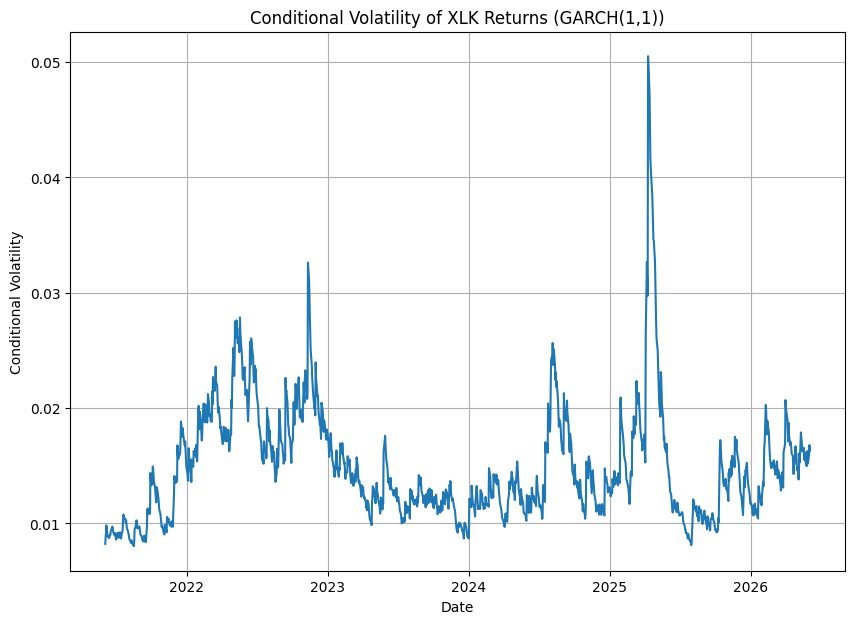

In [12]:
plt.figure(figsize=(10, 7))
plt.plot(results.conditional_volatility)
plt.title('Conditional Volatility of XLK Returns (GARCH(1,1))')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.grid(True)
plt.show()

### The First Linear Regression (Extracting Beta and Epsilon)

In [17]:
import statsmodels.api as sm # Import the main statsmodels API for add_constant

Y = simple_returns['XLK'] # Thematic ETF returns as dependent variable
X = simple_returns['SPY'] # Market proxy returns as independent variable
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    XLK   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     7372.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:46:20   Log-Likelihood:                 4644.6
No. Observations:                1255   AIC:                            -9285.
Df Residuals:                    1253   BIC:                            -9275.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.196      0.2

In [18]:
beta_spy = model.params['SPY']
print(f"Beta (Systematic Loading) for SPY: {beta_spy:.4f}")

Beta (Systematic Loading) for SPY: 1.3500


In [19]:
# Extract the residuals (epsilon)
idiosyncratic_returns = model.resid
print("First 5 rows of Idiosyncratic Returns (Residuals):")
display(idiosyncratic_returns.head())

First 5 rows of Idiosyncratic Returns (Residuals):


,0
Date,
2021-06-04,0.006667
2021-06-07,0.000893
2021-06-08,-0.000418
2021-06-09,0.002526
2021-06-10,0.000874


In [20]:
# Calculate the variance of the residuals (idiosyncratic risk)
idiosyncratic_risk_variance = idiosyncratic_returns.var()
print(f"Variance of Idiosyncratic Returns (Idiosyncratic Risk): {idiosyncratic_risk_variance:.8f}")

Variance of Idiosyncratic Returns (Idiosyncratic Risk): 0.00003576
